# Phase 1: Deep Exploratory Data Analysis (EDA)
This notebook conducts a deep exploratory analysis on the Zindi Liquidity Stress Challenge dataset.
**Goals:**
1. Plot distributions for behavioral and balance features to check for skewness.
2. Implement IQR and Z-score outlier detection on heavy-tailed financial columns (e.g., `highest_amount`, `total_value`).
3. Analyze target distributions.
4. Detect high collinearity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the dataset
print("Loading data...")
df = pd.read_csv('../data/Train.csv')
data_dict = pd.read_csv('../data/data_dictionary.csv')

print(f"Dataset shape: {df.shape}")
target_col = 'liquidity_stress_next_30d'

# Group features based on our data dictionary understanding
profile_cols = [c for c in df.columns if c in ['arpu', 'age', 'gender', 'region', 'smartphone', 'segment', 'earning_pattern']]
balance_cols = [c for c in df.columns if 'avg_bal' in c]
amount_cols = [c for c in df.columns if 'total_value' in c or 'highest_amount' in c]
volume_cols = [c for c in df.columns if 'volume' in c]

df.head()

Loading data...
Dataset shape: (40000, 184)


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,...,m6_withdraw_highest_amount,m6_withdraw_agents,m1_daily_avg_bal,m2_daily_avg_bal,m3_daily_avg_bal,m4_daily_avg_bal,m5_daily_avg_bal,m6_daily_avg_bal,liquidity_stress_next_30d,ID
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,8,58372.55,...,0.00,0,12488.72,11404.86,12943.70,14157.61,13202.11,4336.98,1,ID_C1DF84C4D2
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0,0.00,...,5191.14,4,13677.61,2781.25,5897.59,5416.23,11062.23,4849.68,0,ID_CB8B764D76
2,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,12,41262.86,...,0.00,0,7271.09,5364.41,9023.13,13001.02,17107.92,15174.32,1,ID_D40D58FC67
3,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,10,8738.58,...,8965.63,3,14331.10,33465.26,2973.45,3577.07,18990.91,8488.26,0,ID_CFD8F26581
4,20535.82,63,F,Northern Highlands,No,MVC,Weekly Earner,0.8959,2,3654.68,...,0.00,0,5602.75,8497.49,26252.75,7618.93,9290.65,4214.71,0,ID_20EB501231


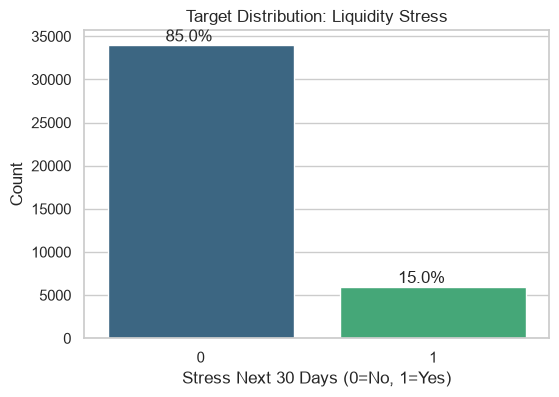

In [3]:
# Target Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=target_col, palette='viridis')
plt.title('Target Distribution: Liquidity Stress')
plt.xlabel('Stress Next 30 Days (0=No, 1=Yes)')
plt.ylabel('Count')

# Add percentages
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

### 2. Outlier Detection on Financial Columns
Financial transaction data is notoriously heavy-tailed. We will analyze the skewness and define capping thresholds using both Z-score and IQR methods.

In [4]:
def analyze_outliers(df, columns):
    outlier_summary = []
    for col in columns:
        if col not in df.columns: continue
        
        # Calculate skewness
        skew = df[col].skew()
        
        # IQR Method
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound_iqr = Q3 + 1.5 * IQR
        outliers_iqr = (df[col] > upper_bound_iqr).sum()
        
        # Z-score Method (Threshold = 3)
        mean, std = df[col].mean(), df[col].std()
        upper_bound_z = mean + 3 * std
        outliers_z = (df[col] > upper_bound_z).sum()
        
        outlier_summary.append({
            'Feature': col,
            'Skewness': skew,
            'IQR_Upper_Bound': upper_bound_iqr,
            'Num_IQR_Outliers': outliers_iqr,
            'Z_Upper_Bound': upper_bound_z,
            'Num_Z_Outliers': outliers_z
        })
        
    return pd.DataFrame(outlier_summary).sort_values(by='Skewness', ascending=False)

# Let's check the highest amount columns across all months
highest_amt_cols = [c for c in amount_cols if 'highest_amount' in c]
outlier_df = analyze_outliers(df, highest_amt_cols)
outlier_df.head(10)

,Feature,Skewness,IQR_Upper_Bound,Num_IQR_Outliers,Z_Upper_Bound,Num_Z_Outliers
15,m4_transfer_from_bank_highest_amount,4.387249,2916.80000,8663,72399.415067,1362
17,m6_transfer_from_bank_highest_amount,4.367477,2942.61875,8719,72239.248778,1378
14,m3_transfer_from_bank_highest_amount,4.356794,2856.68125,8744,72538.508163,1391
12,m1_transfer_from_bank_highest_amount,4.342026,3458.68125,8661,73383.634191,1386
13,m2_transfer_from_bank_highest_amount,4.322941,3270.30625,8763,72673.095152,1398
16,m5_transfer_from_bank_highest_amount,4.304018,3317.54375,8714,73998.302385,1403
9,m4_merchantpay_highest_amount,3.863689,5101.33750,2774,20491.940090,1522
7,m2_merchantpay_highest_amount,3.825406,4988.55625,2808,20795.692543,1572
11,m6_merchantpay_highest_amount,3.825045,5122.89375,2803,20597.631715,1543
6,m1_merchantpay_highest_amount,3.819293,4994.56250,2807,20788.325926,1553


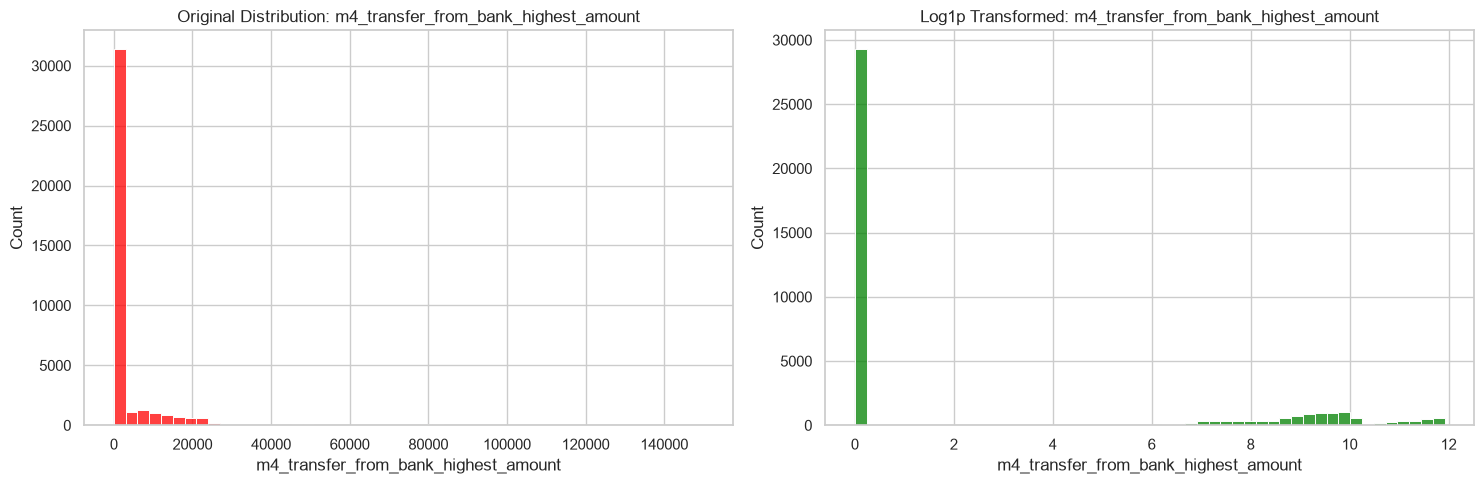

In [5]:
# Let's visualize one of the most skewed features
if not outlier_df.empty:
    skewed_feature = outlier_df.iloc[0]['Feature']

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Original Distribution
    sns.histplot(df[skewed_feature], bins=50, ax=axes[0], color='red')
    axes[0].set_title(f'Original Distribution: {skewed_feature}')

    # Log Transformed Distribution (adding 1 to handle zeros)
    sns.histplot(np.log1p(df[skewed_feature]), bins=50, ax=axes[1], color='green')
    axes[1].set_title(f'Log1p Transformed: {skewed_feature}')

    plt.tight_layout()
    plt.show()

### 3. Deep Collinearity Analysis
Highly collinear features can cause our Neural Network to overfit by memorizing redundant signals. Let's build a correlation matrix of the balance features to see if adjacent months are too highly correlated.

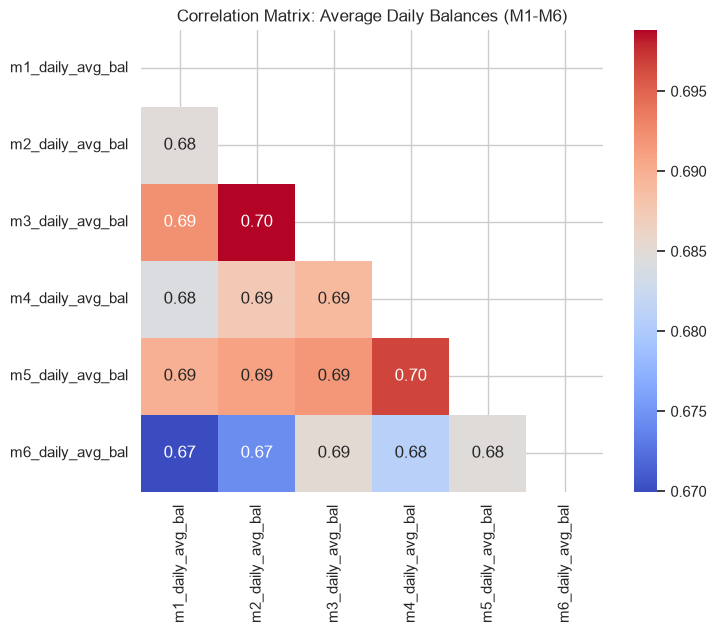

In [6]:
# Correlation Matrix for Balance Columns
if len(balance_cols) > 0:
    plt.figure(figsize=(8, 6))
    corr = df[balance_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Correlation Matrix: Average Daily Balances (M1-M6)')
    plt.show()
else:
    print("Balance columns not found or empty.")